In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from torchvision import datasets, transforms
from rich import print as pr

In [2]:

torch.manual_seed(0)

tfm = transforms.ToTensor()

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=len(train_ds), shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)

train_images, train_labels = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

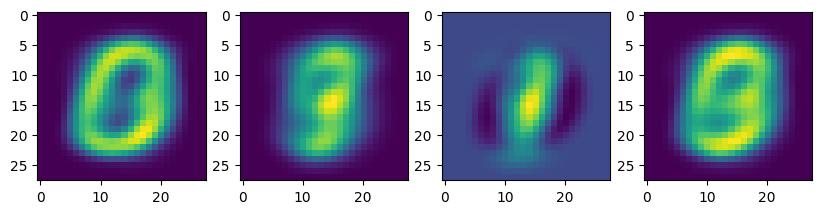

torch.Size([60000, 1]) torch.Size([4, 1]) torch.Size([4, 784])


In [ ]:
torch.manual_seed(0)

X = train_images.view(len(train_images), -1)  
X = X.float()
mean = X.mean(dim=0, keepdim=True)
Xc = X - mean

A, B, C = torch.linalg.svd(Xc, full_matrices=False)

# Xc -> (60000, 784)
k = 2
z = Xc @ C[:k].T  # (60000, 784) @ (2, 784).T = (60000, 2)

z_mean = z.mean(0)
z_std = z.std(0)

num_samples = 4

z_new = torch.randn(num_samples, k) 
z_adj = z_new * z_std + z_mean

z_rec = z_adj @ C[:k] + mean # (60000, 2) @ (2, 784) = (60000, 784)
X_new = torch.clamp(z_rec, 0, 1)

fig, axes = plt.subplots(1,num_samples, figsize=(10,3))
for i, ax in enumerate(axes):
  ax.imshow(z_rec[i].view(28,28))
  # plt.axis('off')

plt.show()

print(z.shape, z_new.shape, z_rec.shape)


torch.Size([1, 784])
torch.Size([10])
X_new torch.Size([10, 784])
Xtest _new torch.Size([10, 784])
tensor(0.)


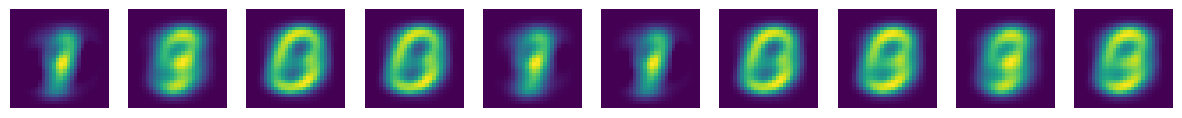

In [ ]:
X = train_images.view(len(train_images), -1)
X = X.float()
mean = X.mean(dim=0, keepdim=True)
print(mean.shape)
Xc = X - mean

U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)

w = Vt[0] 
z = Xc @ w 


z_mean = z.mean()
z_std  = z.std()

num_samples = 10
print(torch.randn(num_samples).shape)

z_new = torch.randn(num_samples) * z_std + z_mean

X_new = z_new[:, None] @ w[None, :] + mean


X_new = torch.clamp(X_new, 0, 1)


fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_new[i].view(28, 28).detach().numpy())
    ax.axis('off')

plt.show()




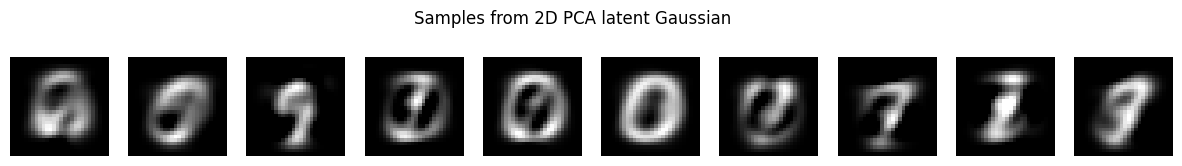

In [37]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from torchvision import datasets, transforms

torch.manual_seed(0)

# ------------------------------------------------------------
# 0. Load MNIST
# ------------------------------------------------------------
tfm = transforms.ToTensor()

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=len(train_ds), shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=len(test_ds),  shuffle=False)

train_images, train_labels = next(iter(train_loader))
test_images,  test_labels  = next(iter(test_loader))

# Flatten images: (N, 784)
X = train_images.view(len(train_images), -1).float()   # [60000, 784]

# ------------------------------------------------------------
# 1. Mean-center
# ------------------------------------------------------------
mean = X.mean(dim=0, keepdim=True)
Xc = X - mean

# ------------------------------------------------------------
# 2. PCA via SVD (we'll use the first TWO principal components)
# ------------------------------------------------------------
U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)   # Xc = U S Vt

# Take the first 2 principal directions
# Vt shape: [784, 784], rows are PCs, so take [:2] then transpose
W = Vt[:6].T      # shape [784, 2]  (columns are PC1, PC2)

# ------------------------------------------------------------
# 3. Project data onto the 2-D latent space: Z = Xc @ W
# ------------------------------------------------------------
Z = Xc @ W        # shape [60000, 2]  (scores)

# ------------------------------------------------------------
# 4. Fit a 2-D Gaussian to Z  (mean + full covariance)
# ------------------------------------------------------------
z_mean = Z.mean(dim=0)                       # [2]
Z_centered = Z - z_mean
# Full 2x2 covariance: (Z^T Z) / (N-1)
cov = (Z_centered.T @ Z_centered) / (Z_centered.shape[0] - 1)   # [2, 2]

# ------------------------------------------------------------
# 5. Sample new latent points from this 2-D Gaussian
# ------------------------------------------------------------
num_samples = 10

dist = torch.distributions.MultivariateNormal(z_mean, covariance_matrix=cov)
z_new = dist.sample((num_samples,))          # shape [10, 2]

# ------------------------------------------------------------
# 6. Decode: X_new = Z_new @ W^T + mean
# ------------------------------------------------------------
X_new = z_new @ W.T + mean                  # [10, 784]
X_new = torch.clamp(X_new, 0, 1)

# ------------------------------------------------------------
# 7. Visualize generated samples
# ------------------------------------------------------------
fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_new[i].view(28, 28).detach().numpy(), cmap='gray')
    ax.axis('off')
plt.suptitle("Samples from 2D PCA latent Gaussian")
plt.show()


